### Graduation Project
## fMRI 3d-CNN Model

Loading data...
Loading and preprocessing images...


100%|██████████████████████████████████████████████████████████████████████████████| 1035/1035 [00:38<00:00, 26.71it/s]



Dataset summary:
Total samples: 1035
ASD cases: 601
Control cases: 434

Visualizing sample brain slices...


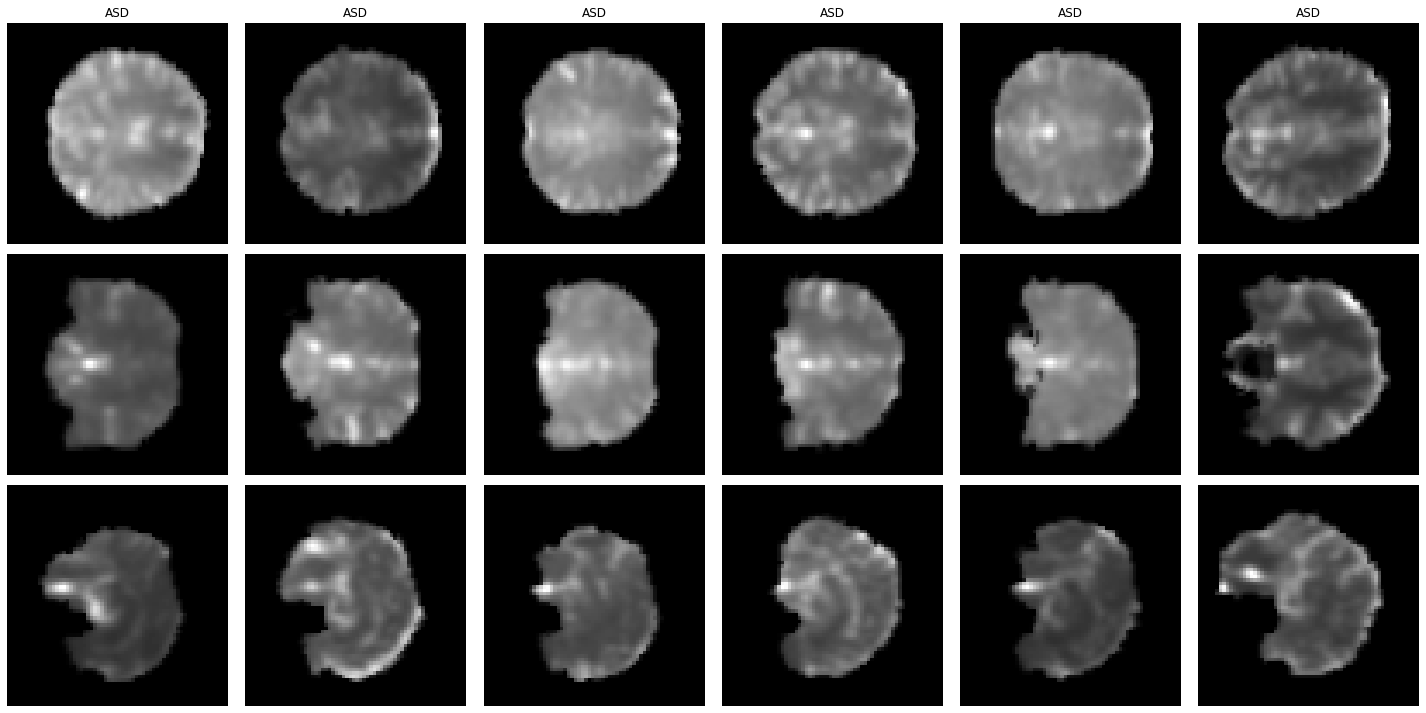

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv3d (Conv3D)             (None, 64, 64, 64, 32)    896       
                                                                 
 batch_normalization (BatchN  (None, 64, 64, 64, 32)   128       
 ormalization)                                                   
                                                                 
 conv3d_1 (Conv3D)           (None, 64, 64, 64, 32)    27680     
                                                                 
 max_pooling3d (MaxPooling3D  (None, 32, 32, 32, 32)   0         
 )                                                               
                                                                 
 dropout (Dropout)           (None, 32, 32, 32, 32)    0         
                                                                 
 conv3d_2 (Conv3D)           (None, 32, 32, 32, 64)    5

In [ ]:
#Claude Model
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import seaborn as sns
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv3D, MaxPooling3D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import Callback, EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import os
from tqdm import tqdm
from IPython.display import clear_output
import tensorflow as tf

# Custom callback for live training visualization
class LiveTrainingCallback(Callback):
    def __init__(self, update_freq=1):
        super(LiveTrainingCallback, self).__init__()
        self.update_freq = update_freq
        self.epochs = []
        self.losses = []
        self.val_losses = []
        self.accuracies = []
        self.val_accuracies = []
        
    def on_epoch_end(self, epoch, logs=None):
        if (epoch % self.update_freq) == 0:
            clear_output(wait=True)
            self.epochs.append(epoch)
            self.losses.append(logs.get('loss'))
            self.val_losses.append(logs.get('val_loss'))
            self.accuracies.append(logs.get('accuracy'))
            self.val_accuracies.append(logs.get('val_accuracy'))
            
            plt.figure(figsize=(15, 5))
            
            # Plot training & validation loss
            plt.subplot(1, 2, 1)
            plt.plot(self.epochs, self.losses, 'b-', label='Training Loss')
            plt.plot(self.epochs, self.val_losses, 'r-', label='Validation Loss')
            plt.title('Model Loss')
            plt.xlabel('Epoch')
            plt.ylabel('Loss')
            plt.legend()
            
            # Plot training & validation accuracy
            plt.subplot(1, 2, 2)
            plt.plot(self.epochs, self.accuracies, 'b-', label='Training Accuracy')
            plt.plot(self.epochs, self.val_accuracies, 'r-', label='Validation Accuracy')
            plt.title('Model Accuracy')
            plt.xlabel('Epoch')
            plt.ylabel('Accuracy')
            plt.legend()
            
            plt.tight_layout()
            plt.show()

def load_and_preprocess_data(data_dir, csv_path):
    """
    Load and preprocess ABIDE fMRI data and labels
    """
    phenotype = pd.read_csv(csv_path)
    images = []
    labels = []
    valid_subjects = []
    
    print("Loading and preprocessing images...")
    file_list = [f for f in os.listdir(data_dir) if f.endswith('.nii.gz')]
    
    for filename in tqdm(file_list):
        try:
            subject_id = '_'.join(filename.split('_')[:2])
            subject_data = phenotype[phenotype['FILE_ID'].str.contains(subject_id, na=False)]
            
            if not subject_data.empty:
                img_path = os.path.join(data_dir, filename)
                img = nib.load(img_path)
                img_data = img.get_fdata()
                
                # Normalize
                img_data = (img_data - img_data.mean()) / (img_data.std() + 1e-10)
                
                # Resize to 64x64x64
                img_data = resize_volume(img_data, (64, 64, 64))
                
                # Add channel dimension
                img_data = np.expand_dims(img_data, axis=-1)
                
                diagnosis = 1 if subject_data['DX_GROUP'].iloc[0] == 1 else 0
                
                images.append(img_data)
                labels.append(diagnosis)
                valid_subjects.append(subject_id)
                
        except Exception as e:
            print(f"\nError processing {filename}: {str(e)}")
    
    return np.array(images), np.array(labels), valid_subjects

def resize_volume(img, target_shape):
    from scipy.ndimage import zoom
    current_shape = img.shape
    factors = [float(target) / current for target, current in zip(target_shape, current_shape)]
    return zoom(img, factors, order=1)

def visualize_brain_slices(image_data, labels, num_samples=6):
    """
    Visualize brain slices in different orientations
    """
    if len(image_data) < num_samples:
        num_samples = len(image_data)
    
    fig = plt.figure(figsize=(20, 10))
    for i in range(num_samples):
        # Sagittal view
        plt.subplot(3, num_samples, i + 1)
        plt.imshow(image_data[i, :, :, image_data.shape[3]//2, 0], cmap='gray')
        if i == 0:
            plt.ylabel('Sagittal')
        plt.title(f'{"ASD" if labels[i] == 1 else "Control"}')
        plt.axis('off')
        
        # Coronal view
        plt.subplot(3, num_samples, i + num_samples + 1)
        plt.imshow(image_data[i, :, image_data.shape[2]//2, :, 0], cmap='gray')
        if i == 0:
            plt.ylabel('Coronal')
        plt.axis('off')
        
        # Axial view
        plt.subplot(3, num_samples, i + 2*num_samples + 1)
        plt.imshow(image_data[i, image_data.shape[1]//2, :, :, 0], cmap='gray')
        if i == 0:
            plt.ylabel('Axial')
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

def create_model(input_shape):
    """
    Create 3D CNN model with improved architecture
    """
    model = Sequential([
        Conv3D(32, kernel_size=3, activation='relu', padding='same', input_shape=input_shape),
        BatchNormalization(),
        Conv3D(32, kernel_size=3, activation='relu', padding='same'),
        MaxPooling3D(pool_size=2),
        Dropout(0.25),
        
        Conv3D(64, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        Conv3D(64, kernel_size=3, activation='relu', padding='same'),
        MaxPooling3D(pool_size=2),
        Dropout(0.25),
        
        Conv3D(128, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        Conv3D(128, kernel_size=3, activation='relu', padding='same'),
        MaxPooling3D(pool_size=2),
        Dropout(0.25),
        
        Flatten(),
        Dense(512, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC()]
    )
    
    return model

def plot_final_metrics(history, y_test, y_pred):
    """
    Plot final evaluation metrics
    """
    plt.figure(figsize=(20, 10))
    
    # Plot training history
    plt.subplot(2, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    
    plt.subplot(2, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    
    # Plot confusion matrix
    plt.subplot(2, 2, 3)
    cm = confusion_matrix(y_test, y_pred.round())
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    
    # Plot ROC curve
    plt.subplot(2, 2, 4)
    fpr, tpr, _ = roc_curve(y_test, y_pred)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc="lower right")
    
    plt.tight_layout()
    plt.show()

def main():
    # Set paths
    data_dir = r"D:\Graduation Project\Data\Brain Scans\ABIDE"
    csv_path = r"C:\Users\Emad\Desktop\Phenotypic_V1_0b_preprocessed1.csv"
    
    # Load and preprocess data
    print("Loading data...")
    X, y, valid_subjects = load_and_preprocess_data(data_dir, csv_path)
    
    print(f"\nDataset summary:")
    print(f"Total samples: {len(X)}")
    print(f"ASD cases: {np.sum(y == 1)}")
    print(f"Control cases: {np.sum(y == 0)}")
    
    # Visualize sample brain slices
    print("\nVisualizing sample brain slices...")
    visualize_brain_slices(X, y)
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
    # Create and compile model
    model = create_model(input_shape=(64, 64, 64, 1))
    model.summary()
    
    # Callbacks
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True
    )
    
    checkpoint = ModelCheckpoint(
        'best_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    )
    
    live_training = LiveTrainingCallback(update_freq=1)
    
    # Train model
    print("\nTraining model...")
    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=100,
        batch_size=8,
        callbacks=[early_stopping, checkpoint, live_training],
        verbose=1
    )
    
    # Evaluate model
    print("\nEvaluating model...")
    y_pred = model.predict(X_test)
    
    # Plot final metrics
    plot_final_metrics(history, y_test, y_pred)
    
    # Print classification report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred.round()))

if __name__ == "__main__":
    main()